# Chapter 6

Add your content here.

Starting Training...
Iter 0: Loss 1.5421
Iter 2000: Loss 0.9599
Iter 4000: Loss 1.0269
Iter 6000: Loss 0.9520
Iter 8000: Loss 0.9940
Training Complete.


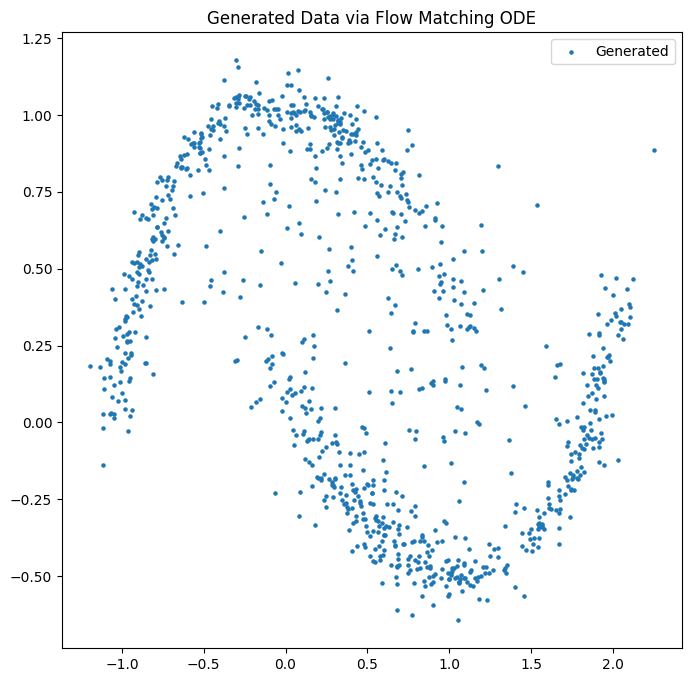

In [1]:

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# 1. Hyperparameters
BATCH_SIZE = 256
lr = 1e-3
iterations = 10000

# 2. Neural Network (Vector Field Approximator)
# Takes input (x, y, t) and outputs velocity (vx, vy)
class VectorField(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64), # Input: 2D position + 1D time
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 2)  # Output: 2D velocity vector
        )

    def forward(self, x, t):
        # Concatenate x and t to form input
        t = t.view(-1, 1) # Ensure shape is (Batch, 1)
        x_input = torch.cat([x, t], dim=1)
        return self.net(x_input)

# 3. Training Loop
model = VectorField()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

print("Starting Training...")
for i in range(iterations):
    optimizer.zero_grad()
    
    # A. Sample Data (x1) - The Target "Moons"
    data, _ = make_moons(n_samples=BATCH_SIZE, noise=0.05)
    x1 = torch.tensor(data, dtype=torch.float32)
    
    # B. Sample Noise (x0) - Standard Gaussian
    x0 = torch.randn_like(x1)
    
    # C. Sample Time t uniformly between 0 and 1
    t = torch.rand(BATCH_SIZE, 1)
    
    # D. Compute the Interpolant (Current Position)
    # formula: psi_t = (1 - t) * x0 + t * x1
    psi_t = (1 - t) * x0 + t * x1
    
    # E. Compute Target Velocity (Conditional Flow)
    # formula: u_t = x1 - x0
    target_velocity = x1 - x0
    
    # F. Network Prediction
    pred_velocity = model(psi_t, t)
    
    # G. Loss: MSE between Prediction and Target
    loss = torch.mean((pred_velocity - target_velocity)**2)
    
    loss.backward()
    optimizer.step()
    
    if i % 2000 == 0:
        print(f"Iter {i}: Loss {loss.item():.4f}")

print("Training Complete.")

# 4. Inference (Generation) via Euler Integration
# We start at noise and follow the learned vector field
def generate_samples(model, n_samples=1000, steps=100):
    model.eval()
    # Start at x0 (Noise)
    x = torch.randn(n_samples, 2)
    dt = 1.0 / steps
    
    traj = [x.detach().numpy()] # Store trajectory for visualization
    
    with torch.no_grad():
        for i in range(steps):
            t_val = i / steps
            # Create a tensor of constant time for the batch
            t_batch = torch.full((n_samples, 1), t_val)
            
            # Get velocity from model
            velocity = model(x, t_batch)
            
            # Update position: x_new = x_old + v * dt (Euler Method)
            x = x + velocity * dt
            traj.append(x.detach().numpy())
            
    return x.detach().numpy(), np.array(traj)

# 5. Visualization
generated_data, trajectory = generate_samples(model)

plt.figure(figsize=(8, 8))
plt.scatter(generated_data[:, 0], generated_data[:, 1], s=5, label='Generated')
plt.title("Generated Data via Flow Matching ODE")
plt.legend()
plt.show()